# Quantitative Trading Architecture: Multi-Frequency Extrema Distillation

This architecture targets **Reversal Zone** detection using a Dual-Teacher Setup and a Tri-Loss Formulation.
Target labels are generated using a Coarse-to-Fine Extrema Scanner with dynamic padding and prominence filtering.
Evaluation relies on a strict Train/Validate/Test split, where the validation set derives mathematically robust execution thresholds via grid-search.

In [1]:
!pip install TA-Lib mplfinance quantstats seaborn scikit-learn yfinance

In [2]:
import math
import copy
import warnings
import itertools
import numpy as np
import pandas as pd
import yfinance as yf
import talib
from scipy.signal import find_peaks

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import quantstats as qs

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {DEVICE}")

Using compute device: cuda


## Phase I: Multi-Frequency Feature Engineering & Oracle Extrema Labeling

In [3]:
class MarketDataPipeline:
    def __init__(self, ticker, start_date, end_date, time_steps=5):
        self.ticker = ticker
        self.start_date = pd.to_datetime(start_date) - pd.Timedelta(days=400)
        self.end_date = end_date
        self.time_steps = time_steps

        # 7 Micro Features, 6 Macro Features (Total = 13)
        self.micro_cols = ['Micro_RSI', 'Micro_RSI_Slope', 'Micro_FastK', 'Micro_FastD', 'Micro_Prc_Dev', 'Micro_Vol_Burst', 'Micro_Ret_Accel']
        self.macro_cols = ['Macro_RSI', 'Macro_FastK', 'Macro_FastD', 'Macro_Prc_Dev', 'Macro_Vol_Base', 'Macro_Ret_Vel']
        self.feature_columns = self.micro_cols + self.macro_cols

    def fetch_data(self):
        df = yf.download(self.ticker, start=self.start_date, end=self.end_date, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df.dropna()

    def compute_features(self, df):
        # --- Micro Features ---
        df['Micro_RSI'] = talib.RSI(df['Close'], timeperiod=14) / 100.0
        df['Micro_RSI_Slope'] = df['Micro_RSI'].diff(3)

        fastk, fastd = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=5, fastd_period=3, fastd_matype=0)
        df['Micro_FastK'] = fastk / 100.0
        df['Micro_FastD'] = fastd / 100.0

        sma_20 = talib.SMA(df['Close'], timeperiod=20)
        df['Micro_Prc_Dev'] = (df['Close'] / sma_20) - 1.0
        sma_vol_20 = talib.SMA(df['Volume'], timeperiod=20).replace(0, np.nan)
        df['Micro_Vol_Burst'] = (df['Volume'] / sma_vol_20).fillna(1.0)

        daily_ret = df['Close'].pct_change()
        sma_ret_5 = daily_ret.rolling(window=5).mean()
        df['Micro_Ret_Accel'] = daily_ret - sma_ret_5

        # --- Macro Features ---
        df['Macro_RSI'] = talib.RSI(df['Close'], timeperiod=50) / 100.0
        fastk_m, fastd_m = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=20, fastd_period=5, fastd_matype=0)
        df['Macro_FastK'] = fastk_m / 100.0
        df['Macro_FastD'] = fastd_m / 100.0
        sma_200 = talib.SMA(df['Close'], timeperiod=200)
        df['Macro_Prc_Dev'] = (df['Close'] / sma_200) - 1.0
        sma_vol_100 = talib.SMA(df['Volume'], timeperiod=100).replace(0, np.nan)
        df['Macro_Vol_Base'] = (sma_vol_20 / sma_vol_100).fillna(1.0)
        df['Macro_Ret_Vel'] = df['Close'] / df['Close'].shift(10) - 1.0

        df['5D_MA'] = talib.SMA(df['Close'], timeperiod=5)
        df['20D_MA'] = sma_20
        return df.fillna(0)

    def assign_dynamic_labels(self, prices, extrema_indices, extrema_types, max_pad=2):
        labels = np.full(len(prices), 2) # Default to Class 2 (Trend)
        n_extrema = len(extrema_indices)

        for i in range(n_extrema):
            curr_idx = extrema_indices[i]
            curr_type = extrema_types[i]

            dist_prev = (curr_idx - extrema_indices[i-1]) if i > 0 else max_pad * 2 + 1
            dist_next = (extrema_indices[i+1] - curr_idx) if i < n_extrema - 1 else max_pad * 2 + 1

            pad_left = min(max_pad, max(0, (dist_prev - 1) // 2))
            pad_right = min(max_pad, max(0, (dist_next - 1) // 2))

            labels[curr_idx - pad_left : curr_idx + pad_right + 1] = curr_type
        return labels

    def generate_labels(self, df):
        prices = df['Close'].values
        sma_10 = talib.SMA(prices, timeperiod=10)
        valid_idx = ~np.isnan(sma_10)

        # Prominence Filtering (Require a 3% structural swing)
        min_swing = np.nanmean(sma_10) * 0.03
        coarse_peaks, _ = find_peaks(sma_10[valid_idx], distance=5, prominence=min_swing)
        coarse_troughs, _ = find_peaks(-sma_10[valid_idx], distance=5, prominence=min_swing)

        offset = np.argmax(valid_idx)
        coarse_peaks += offset
        coarse_troughs += offset

        fine_extrema = []
        for cp in coarse_peaks:
            start = max(0, cp - 3)
            end = min(len(prices), cp + 4)
            fine_idx = start + np.argmax(prices[start:end])
            fine_extrema.append((fine_idx, 1))

        for ct in coarse_troughs:
            start = max(0, ct - 3)
            end = min(len(prices), ct + 4)
            fine_idx = start + np.argmin(prices[start:end])
            fine_extrema.append((fine_idx, 0))

        fine_extrema = sorted(list(set(fine_extrema)), key=lambda x: x[0])

        if len(fine_extrema) > 0:
            ext_indices, ext_types = zip(*fine_extrema)
            labels = self.assign_dynamic_labels(prices, ext_indices, ext_types, max_pad=2)
        else:
            labels = np.full(len(prices), 2)

        df['Regime'] = labels
        return df.dropna()

    def prepare_data(self, val_days, test_days):
        raw_df = self.fetch_data()
        df = self.compute_features(raw_df)
        self.clean_df = self.generate_labels(df)

        features = self.clean_df[self.feature_columns].values
        labels = self.clean_df['Regime'].values

        X, Y = [], []
        for i in range(len(features) - self.time_steps + 1):
            X.append(features[i:(i + self.time_steps)])
            Y.append(labels[i + self.time_steps - 1])

        X, Y = np.array(X), np.array(Y, dtype=np.int64)
        self.clean_df = self.clean_df.iloc[-len(X):].copy()

        test_idx = len(X) - test_days
        val_idx = test_idx - val_days

        X_train, X_val, X_test = X[:val_idx], X[val_idx:test_idx], X[test_idx:]
        Y_train, Y_val, Y_test = Y[:val_idx], Y[val_idx:test_idx], Y[test_idx:]

        self.scaler = StandardScaler()
        B, T, F = X_train.shape
        X_train_reshaped = X_train.reshape(-1, F)
        self.scaler.fit(X_train_reshaped)

        X_train = self.scaler.transform(X_train_reshaped).reshape(B, T, F)
        X_val = self.scaler.transform(X_val.reshape(-1, F)).reshape(X_val.shape[0], T, F)
        X_test = self.scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape[0], T, F)

        return X_train, X_val, X_test, Y_train, Y_val, Y_test, self.clean_df

## Phase II: Neural Network Architecture & Tri-Loss Distillation

In [4]:
class RegimeGRU(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, output_size=3, dropout_prob=0.3):
        super(RegimeGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_dim, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        logits = self.fc(out)
        return logits

class SGLDOptimizer(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, noise_scale=0.01, weight_decay=1e-4):
        defaults = dict(lr=lr, noise_scale=noise_scale, weight_decay=weight_decay)
        super(SGLDOptimizer, self).__init__(params, defaults)

    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                if group['weight_decay'] != 0:
                    p.grad.data.add_(p.data, alpha=group['weight_decay'])
                lr = group['lr']
                noise = torch.randn_like(p.data) * math.sqrt(2.0 * lr) * group['noise_scale']
                p.data.add_(p.grad.data, alpha=-lr)
                p.data.add_(noise)
        return loss

def tri_master_distillation_loss(student_logits, micro_logits, macro_logits, true_labels, class_weights=None, a=0.4, b=0.3, c=0.3, temp=2.0):
    if class_weights is not None:
        hard_loss = F.cross_entropy(student_logits, true_labels, weight=class_weights, reduction='none')
    else:
        hard_loss = F.cross_entropy(student_logits, true_labels, reduction='none')

    soft_micro = F.kl_div(
        F.log_softmax(student_logits / temp, dim=1),
        F.softmax(micro_logits / temp, dim=1),
        reduction='none'
    ).sum(dim=1) * (temp ** 2)

    soft_macro = F.kl_div(
        F.log_softmax(student_logits / temp, dim=1),
        F.softmax(macro_logits / temp, dim=1),
        reduction='none'
    ).sum(dim=1) * (temp ** 2)

    total_loss = (a * hard_loss) + (b * soft_macro) + (c * soft_micro)
    return total_loss.mean()

## Phase III: Expert Teacher Training & Validation

Preparing Centered Data Pipeline (Train / Val / Test)...

--- CHECKPOINT 1: Teacher Model Validation ---


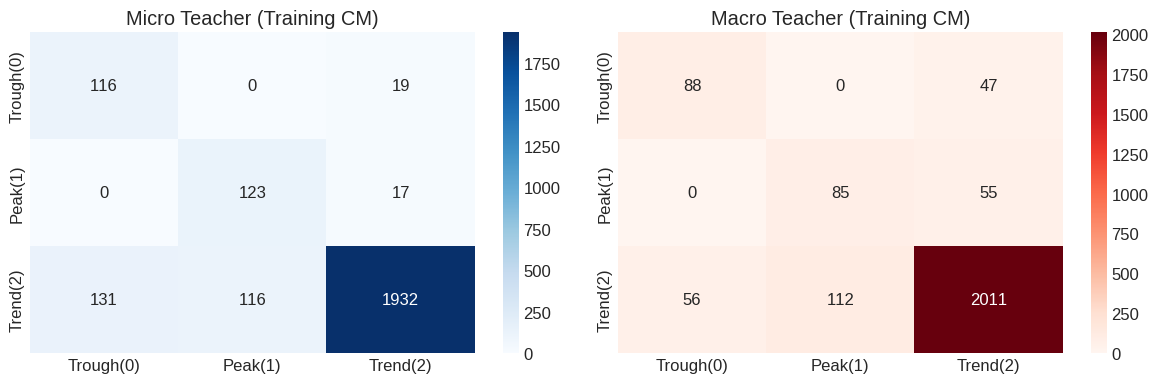

In [18]:
def train_teacher(model, X_train, Y_train, epochs=150, lr=1e-3):
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=96, shuffle=True)

    class_counts = np.bincount(Y_train)
    raw_weights = len(Y_train) / (len(class_counts) * class_counts)
    dampened_weights = np.sqrt(raw_weights)
    dampened_weights = dampened_weights / np.sum(dampened_weights) * len(class_counts)
    class_weights = torch.tensor(dampened_weights, dtype=torch.float32).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    model.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx.to(DEVICE)), by.to(DEVICE))
            loss.backward()
            optimizer.step()
    model.eval()

def plot_teacher_confusion_matrices(teacher_micro, teacher_macro, X_micro, X_macro, Y_train):
    print("\n--- CHECKPOINT 1: Teacher Model Validation ---")
    X_t_mic = torch.tensor(X_micro, dtype=torch.float32).to(DEVICE)
    X_t_mac = torch.tensor(X_macro, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        preds_mic = torch.argmax(teacher_micro(X_t_mic), dim=1).cpu().numpy()
        preds_mac = torch.argmax(teacher_macro(X_t_mac), dim=1).cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(confusion_matrix(Y_train, preds_mic), annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'], yticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'])
    ax[0].set_title("Micro Teacher (Training CM)")

    sns.heatmap(confusion_matrix(Y_train, preds_mac), annot=True, fmt='d', cmap='Reds', ax=ax[1],
                xticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'], yticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'])
    ax[1].set_title("Macro Teacher (Training CM)")
    plt.tight_layout()
    plt.show()

# --- EXECUTION: DATA PIPELINE & TEACHERS ---
TICKER = "^HSI"
START_DATE = "2013-01-01"
END_DATE = "2026-01-01"
VAL_DAYS_N = 504
TEST_DAYS_N = 504

print("Preparing Centered Data Pipeline (Train / Val / Test)...")
pipeline = MarketDataPipeline(ticker=TICKER, start_date=START_DATE, end_date=END_DATE, time_steps=5)
X_train, X_val, X_test, Y_train, Y_val, Y_test, clean_df = pipeline.prepare_data(val_days=VAL_DAYS_N, test_days=TEST_DAYS_N)

# Feature Slicing (7 Micro, 6 Macro)
X_train_micro = X_train[:, :, :7]
X_train_macro = X_train[:, :, 7:]

teacher_micro = RegimeGRU(7, 32, 1, dropout_prob=0.3).to(DEVICE)
teacher_macro = RegimeGRU(6, 32, 1, dropout_prob=0.3).to(DEVICE)

train_teacher(teacher_micro, X_train_micro, Y_train, epochs=150)
train_teacher(teacher_macro, X_train_macro, Y_train, epochs=150)

plot_teacher_confusion_matrices(teacher_micro, teacher_macro, X_train_micro, X_train_macro, Y_train)

## Phase IV: SGLD Student Distillation & Uncertainty Calibration


--- CHECKPOINT 2: Training Tri-Loss SGLD Student ---

--- CHECKPOINT 2b: Student Ensemble Validation (Training CM) ---


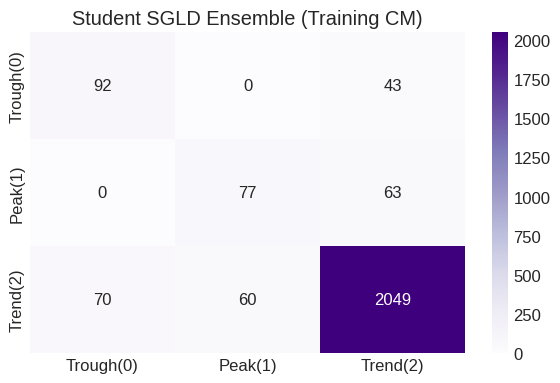

In [19]:
def train_student_tri_loss_annealed(student, t_micro, t_macro, X_train, Y_train, epochs=300, burn_in=150, thinning=5):
    print(f"\n--- CHECKPOINT 2: Training Tri-Loss SGLD Student ---")
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=96, shuffle=True)

    optimizer_adam = torch.optim.Adam(student.parameters(), lr=1e-3, weight_decay=1e-4)
    optimizer_sgld = SGLDOptimizer(student.parameters(), lr=5e-4, noise_scale=0.005)

    class_counts = np.bincount(Y_train)
    raw_weights = len(Y_train) / (len(class_counts) * class_counts)
    dampened_weights = np.sqrt(raw_weights)
    dampened_weights = dampened_weights / np.sum(dampened_weights) * len(class_counts)
    class_weights = torch.tensor(dampened_weights, dtype=torch.float32).to(DEVICE)

    mc_samples = []

    for epoch in range(epochs):
        student.train()
        current_optimizer = optimizer_adam if epoch < burn_in else optimizer_sgld

        for bx, by in loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)

            bx_micro = bx[:, :, :7]
            bx_macro = bx[:, :, 7:]

            with torch.no_grad():
                micro_logits = t_micro(bx_micro)
                macro_logits = t_macro(bx_macro)

            current_optimizer.zero_grad()
            student_logits = student(bx)
            loss = tri_master_distillation_loss(student_logits, micro_logits, macro_logits, by, class_weights=class_weights)
            loss.backward()
            current_optimizer.step()

        if epoch >= burn_in and epoch % thinning == 0:
            mc_samples.append({k: v.cpu() for k, v in copy.deepcopy(student.state_dict()).items()})

    student.eval()
    return mc_samples

def predict_intervals(student, mc_samples, X):
    X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    all_probs = []
    with torch.no_grad():
        for state in mc_samples:
            student.load_state_dict(state)
            all_probs.append(F.softmax(student(X_tensor), dim=1).cpu().numpy())

    all_probs = np.array(all_probs)
    mean_probs = np.mean(all_probs, axis=0)
    spreads = np.percentile(all_probs, 95, axis=0) - np.percentile(all_probs, 5, axis=0)
    return mean_probs, spreads

def plot_student_ensemble_cm(student, mc_samples, X_train, Y_train):
    print("\n--- CHECKPOINT 2b: Student Ensemble Validation (Training CM) ---")
    mean_probs_train, _ = predict_intervals(student, mc_samples, X_train)
    preds_train = np.argmax(mean_probs_train, axis=1)

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(Y_train, preds_train), annot=True, fmt='d', cmap='Purples',
                xticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'],
                yticklabels=['Trough(0)', 'Peak(1)', 'Trend(2)'])
    plt.title("Student SGLD Ensemble (Training CM)")
    plt.tight_layout()
    plt.show()

# --- EXECUTION: STUDENT SGLD ---
student_model = RegimeGRU(13, 16, 1, dropout_prob=0.3).to(DEVICE)
mc_samples_student = train_student_tri_loss_annealed(student_model, teacher_micro, teacher_macro, X_train, Y_train)

plot_student_ensemble_cm(student_model, mc_samples_student, X_train, Y_train)
mean_probs_val, spreads_val = predict_intervals(student_model, mc_samples_student, X_val)
mean_probs_test, spreads_test = predict_intervals(student_model, mc_samples_student, X_test)

## Phase V: Validation Profiling Lab

In [20]:
def profile_validation_extrema(clean_df, val_days, test_days, mean_probs, spreads):
    val_data = clean_df.iloc[-(val_days + test_days):-test_days].copy()
    min_n = min(len(val_data), len(mean_probs))
    val_data = val_data.iloc[-min_n:].copy()

    val_data['Prob_Trough'] = mean_probs[-min_n:, 0]
    val_data['Prob_Peak']   = mean_probs[-min_n:, 1]
    val_data['SGLD_Spread'] = np.max(spreads[-min_n:], axis=1)

    prices = val_data['Close'].values
    dates = val_data.index

    sma_10 = talib.SMA(prices, timeperiod=10)
    valid_idx = ~np.isnan(sma_10)
    min_swing = np.nanmean(sma_10) * 0.03
    coarse_peaks, _ = find_peaks(sma_10[valid_idx], distance=5, prominence=min_swing)
    coarse_troughs, _ = find_peaks(-sma_10[valid_idx], distance=5, prominence=min_swing)

    offset = np.argmax(valid_idx)
    coarse_peaks += offset
    coarse_troughs += offset

    records = []

    for ct in coarse_troughs:
        start = max(0, ct - 3)
        end = min(len(prices), ct + 4)
        local_min_idx = start + np.argmin(prices[start:end])

        r_min = val_data.iloc[local_min_idx]
        records.append({
            'Date': str(dates[local_min_idx].date()), 'Extremum': 'Trough(Buy)',
            'Price': round(float(r_min['Close']), 2),
            'Prob_Trough': round(float(r_min['Prob_Trough']), 3),
            'Prob_Peak': round(float(r_min['Prob_Peak']), 3),
            'Uncertainty_Spread': round(float(r_min['SGLD_Spread']), 3)
        })

    for cp in coarse_peaks:
        start = max(0, cp - 3)
        end = min(len(prices), cp + 4)
        local_max_idx = start + np.argmax(prices[start:end])

        r_max = val_data.iloc[local_max_idx]
        records.append({
            'Date': str(dates[local_max_idx].date()), 'Extremum': 'Peak(Sell)',
            'Price': round(float(r_max['Close']), 2),
            'Prob_Trough': round(float(r_max['Prob_Trough']), 3),
            'Prob_Peak': round(float(r_max['Prob_Peak']), 3),
            'Uncertainty_Spread': round(float(r_max['SGLD_Spread']), 3)
        })

    profile_df = pd.DataFrame(records).sort_values(by='Date').drop_duplicates(subset=['Date', 'Extremum']).reset_index(drop=True)
    print(f"\n--- VALIDATION EXTREMA PROFILING (Logged: {len(profile_df)}) ---")
    return profile_df

# --- EXECUTION: PROFILER ---
validation_profile_df = profile_validation_extrema(clean_df, VAL_DAYS_N, TEST_DAYS_N, mean_probs_val, spreads_val)
pd.set_option('display.max_rows', None)
display(validation_profile_df)


--- VALIDATION EXTREMA PROFILING (Logged: 14) ---


,Date,Extremum,Price,Prob_Trough,Prob_Peak,Uncertainty_Spread
0,2022-01-05,Trough(Buy),22907.25,0.002,0.001,0.000
1,2022-02-17,Peak(Sell),24792.77,0.000,0.434,0.030
2,2022-03-15,Trough(Buy),18415.08,0.083,0.000,0.007
3,2022-04-04,Peak(Sell),22502.31,0.001,0.126,0.011
4,2022-05-24,Trough(Buy),20112.10,0.000,0.001,0.000
5,2022-07-05,Peak(Sell),21853.07,0.000,0.693,0.035
6,2022-11-03,Trough(Buy),15339.49,0.272,0.000,0.032
7,2023-02-01,Peak(Sell),22072.18,0.000,0.745,0.040
8,2023-03-20,Trough(Buy),19000.71,0.208,0.000,0.017
9,2023-04-17,Peak(Sell),20782.45,0.000,0.282,0.031


## Phase VI: Validation Grid Search & Out-of-Sample Execution


In [ ]:
def validation_grid_search(clean_df, val_days, test_days, mean_probs, spreads):
    print("\n--- RUNNING VALIDATION GRID SEARCH (Relaxed 1.5% Tx Penalty) ---")
    val_data = clean_df.iloc[-(val_days + test_days):-test_days].copy()
    min_n = min(len(val_data), len(mean_probs))
    val_data = val_data.iloc[-min_n:].copy()

    val_data['Prob_Trough'] = mean_probs[-min_n:, 0]
    val_data['Prob_Peak']   = mean_probs[-min_n:, 1]
    val_data['Prob_Trend']  = mean_probs[-min_n:, 2]

    sorted_probs = np.sort(mean_probs[-min_n:], axis=1)
    val_data['Prob_Margin'] = sorted_probs[:, -1] - sorted_probs[:, -2]
    val_data['SGLD_Spread'] = np.max(spreads[-min_n:], axis=1)

    # Expanded Search Space for capturing intermediate swings
    # Testing margins from a highly sensitive 5% lead to a strict 55% lead
    grid_margins = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
    # Testing tight to moderate uncertainty thresholds
    grid_buy_spreads = [0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10]
    # Testing moderate to wide chaos veto thresholds
    grid_veto_spreads = [0.05, 0.08, 0.10, 0.12, 0.15]

    best_score = -999.0
    best_params = None

    for margin_thr, buy_spr, veto_spr in itertools.product(grid_margins, grid_buy_spreads, grid_veto_spreads):
        cash = 100000.0
        holdings = 0.0
        in_position = False
        strategy_values = []
        trades = 0

        for i in range(len(val_data)):
            price = val_data['Close'].iloc[i]
            open_price = val_data['Open'].iloc[i]

            if i == 0:
                strategy_values.append(cash)
                continue

            prev = val_data.iloc[i-1]

            is_trough = (prev['Prob_Trough'] > prev['Prob_Peak']) and (prev['Prob_Trough'] > prev['Prob_Trend'])
            is_peak = (prev['Prob_Peak'] > prev['Prob_Trough']) and (prev['Prob_Peak'] > prev['Prob_Trend'])

            go_long = is_trough and (prev['Prob_Margin'] > margin_thr) and (prev['SGLD_Spread'] < buy_spr)
            force_liquidate = (is_peak and (prev['Prob_Margin'] > margin_thr)) or (prev['SGLD_Spread'] > veto_spr)

            if go_long and not force_liquidate and not in_position:
                # REVISED: 1.5% simulated fee allows intermediate trades
                execution_price = open_price * 1.03
                holdings = cash / execution_price
                cash = 0.0
                in_position = True
                trades += 1
            elif force_liquidate and in_position:
                execution_price = open_price * 0.97
                cash = holdings * execution_price
                holdings = 0.0
                in_position = False
                trades += 1

            strategy_values.append(cash + (holdings * price))

        val_data['Strat_Val'] = strategy_values
        strat_ret = val_data['Strat_Val'].pct_change().dropna()

        if trades < 2 or strat_ret.std() == 0:
            sortino = -999.0
        else:
            try:
                sortino = qs.stats.sortino(strat_ret, rf=0.0)
                if np.isnan(sortino): sortino = -999.0
            except:
                sortino = -999.0

        if sortino > best_score:
            best_score = sortino
            best_params = (margin_thr, buy_spr, veto_spr, trades)

    print(f"Optimal Vals -> Margin > {best_params[0]} | Buy Spread < {best_params[1]} | Veto Spread > {best_params[2]} | Trades: {best_params[3]}")
    return best_params


def run_extrema_backtest(clean_df, test_days, mean_probs, spreads, params):
    print(f"\n--- CHECKPOINT 3: Out-of-Sample Test Set Execution ---")
    data = clean_df.iloc[-test_days:].copy()
    min_n = min(len(data), len(mean_probs))
    data = data.iloc[-min_n:].copy()

    data['Prob_Trough'] = mean_probs[-min_n:, 0]
    data['Prob_Peak']   = mean_probs[-min_n:, 1]
    data['Prob_Trend']  = mean_probs[-min_n:, 2]

    sorted_probs = np.sort(mean_probs[-min_n:], axis=1)
    data['Prob_Margin'] = sorted_probs[:, -1] - sorted_probs[:, -2]
    data['SGLD_Spread'] = np.max(spreads[-min_n:], axis=1)

    margin_thr, buy_spr, veto_spr, _ = params

    cash = 100000.0
    holdings = 0.0
    in_position = False
    strategy_values = []
    buy_markers = [np.nan] * len(data)
    sell_markers = [np.nan] * len(data)

    start_price = data['Close'].iloc[0]
    data['Benchmark'] = data['Close'] * (100000.0 / start_price)

    for i in range(len(data)):
        price = data['Close'].iloc[i]
        open_price = data['Open'].iloc[i]

        if i == 0:
            strategy_values.append(cash)
            continue

        prev = data.iloc[i-1]

        is_trough = (prev['Prob_Trough'] > prev['Prob_Peak']) and (prev['Prob_Trough'] > prev['Prob_Trend'])
        is_peak = (prev['Prob_Peak'] > prev['Prob_Trough']) and (prev['Prob_Peak'] > prev['Prob_Trend'])

        go_long = is_trough and (prev['Prob_Margin'] > margin_thr) and (prev['SGLD_Spread'] < buy_spr)
        force_liquidate = (is_peak and (prev['Prob_Margin'] > margin_thr)) or (prev['SGLD_Spread'] > veto_spr)

        if go_long and not force_liquidate and not in_position:
            execution_price = open_price * 1.0005
            holdings = cash / execution_price
            cash = 0.0
            in_position = True
            buy_markers[i] = data['Low'].iloc[i] * 0.99

        elif force_liquidate and in_position:
            execution_price = open_price * 0.9995
            cash = holdings * execution_price
            holdings = 0.0
            in_position = False
            sell_markers[i] = data['High'].iloc[i] * 1.01

        strategy_values.append(cash + (holdings * price))

    data['Strategy'] = strategy_values
    strat_ret = data['Strategy'].pct_change().dropna()
    bench_ret = data['Benchmark'].pct_change().dropna()
    strat_ret.index = pd.to_datetime(strat_ret.index)
    bench_ret.index = pd.to_datetime(bench_ret.index)

    qs.reports.metrics(strat_ret, benchmark=bench_ret, prepare_returns=False)

    apds = [
        mpf.make_addplot(data['5D_MA'], color='blue', panel=0, width=1.0),
        mpf.make_addplot(data['20D_MA'], color='orange', panel=0, width=1.0),
        mpf.make_addplot(data['Volume'], type='bar', color='gray', panel=1, alpha=0.5),
        mpf.make_addplot(data['SGLD_Spread'], color='purple', panel=2, ylabel='Uncertainty'),
        mpf.make_addplot([buy_spr]*len(data), color='green', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot([veto_spr]*len(data), color='red', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot(data['Strategy'], panel=3, color='darkgreen', ylabel='Equity', width=1.5),
        mpf.make_addplot(data['Benchmark'], panel=3, color='gray', linestyle='--', width=1.0)
    ]
    if pd.Series(buy_markers).notna().any():
        apds.append(mpf.make_addplot(buy_markers, type='scatter', markersize=80, marker='^', color='lime', panel=0))
    if pd.Series(sell_markers).notna().any():
        apds.append(mpf.make_addplot(sell_markers, type='scatter', markersize=80, marker='v', color='red', panel=0))

    mpf.plot(data, type='candle', addplot=apds, panel_ratios=(4, 1, 1, 2), figratio=(12, 12), figscale=1.2, title='OOS Margin-Based Extrema Backtest')

# --- EXECUTION: OPTIMIZE & TEST ---
optimal_params = validation_grid_search(clean_df, VAL_DAYS_N, TEST_DAYS_N, mean_probs_val, spreads_val)
if optimal_params:
    run_extrema_backtest(clean_df, TEST_DAYS_N, mean_probs_test, spreads_test, optimal_params)
else:
    print("Optimization returned no valid parameters.")


--- RUNNING VALIDATION GRID SEARCH (Relaxed 1.5% Tx Penalty) ---


## Phase VII: Generalized 2D Heatmaps (Decision Boundaries)

The non-linear decision boundaries formulated by the Tri-Loss Student can be visualized to ensure the architecture relies on sound topographical contours when segregating Trough (0), Peak (1), and Trend (2) reversal zones.

In [ ]:
def plot_all_2d_pdp_heatmaps(student_model, scaler, feature_names, X_train):
    print("\n--- GENERATING 2D DECISION BOUNDARY HEATMAPS ---")
    feature_pairs = list(itertools.combinations(feature_names[:4], 2))

    X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
    X_train_orig = scaler.inverse_transform(X_train_reshaped)
    medians = np.median(X_train_orig, axis=0)

    student_model.eval()

    for f_x, f_y in feature_pairs:
        idx_x = feature_names.index(f_x)
        idx_y = feature_names.index(f_y)

        x_min, x_max = np.percentile(X_train_orig[:, idx_x], [5, 95])
        y_min, y_max = np.percentile(X_train_orig[:, idx_y], [5, 95])

        x_range = np.linspace(x_min, x_max, 40)
        y_range = np.linspace(y_min, y_max, 40)
        XX, YY = np.meshgrid(x_range, y_range)

        Z_trough = np.zeros(XX.shape)
        Z_peak = np.zeros(XX.shape)

        for i in range(XX.shape[0]):
            for j in range(XX.shape[1]):
                features = medians.copy()
                features[idx_x] = XX[i, j]
                features[idx_y] = YY[i, j]

                seq = np.tile(features, (5, 1))
                seq_scaled = scaler.transform(seq)
                t_input = torch.tensor(seq_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    probs = F.softmax(student_model(t_input), dim=1).cpu().numpy()[0]
                    Z_trough[i, j] = probs[0]
                    Z_peak[i, j] = probs[1]

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        c1 = ax[0].contourf(XX, YY, Z_trough, levels=20, cmap='Greens')
        ax[0].set_title('Probability of TROUGH (Buy)')
        ax[0].set_xlabel(f_x)
        ax[0].set_ylabel(f_y)
        fig.colorbar(c1, ax=ax[0])

        c2 = ax[1].contourf(XX, YY, Z_peak, levels=20, cmap='Reds')
        ax[1].set_title('Probability of PEAK (Sell)')
        ax[1].set_xlabel(f_x)
        ax[1].set_ylabel(f_y)
        fig.colorbar(c2, ax=ax[1])
        plt.tight_layout()
        plt.show()

# --- EXECUTION: HEATMAPS ---
plot_all_2d_pdp_heatmaps(student_model, pipeline.scaler, pipeline.feature_columns, X_train)